In [2]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

current_directory = Path.cwd()

if (current_directory / "src").is_dir():
    PROJECT_ROOT = current_directory
elif (current_directory.parent / "src").is_dir():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Run the notebook from he project or notebooks folder."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.preprocessing import (
    FEATURES,
    prepare_features,
    create_preprocessor
)

PROCESSED_DIRECTORY = PROJECT_ROOT / "data" / "processed"
MODELS_DIRECTORY = PROJECT_ROOT / "models"
FIGURES_DIRECTORY = PROJECT_ROOT / "reports" / "figures"
METRICS_DIRECTORY = PROJECT_ROOT / "reports" / "metrics"

for directory in [
    PROCESSED_DIRECTORY,
    MODELS_DIRECTORY,
    FIGURES_DIRECTORY,
    METRICS_DIRECTORY,
]:
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

In [3]:
train_data = pd.read_csv(
    PROCESSED_DIRECTORY / "train_raw.csv",
    index_col="source_row"
)

test_data = pd.read_csv(
    PROCESSED_DIRECTORY / "test_raw.csv",
    index_col="source_row"
)

assert train_data.index.is_unique
assert test_data.index.is_unique

# Check that the training and test sets do not overlap have no ele in common 
assert set(train_data.index).isdisjoint(test_data.index)

print("Training shape:", train_data.shape)
print("Test shape:", test_data.shape)


Training shape: (614, 9)
Test shape: (154, 9)


In [4]:
X_train_clean = prepare_features(train_data)

missing_report = pd.DataFrame({
    "missing_count": X_train_clean.isna().sum(),
    "missing_percent" : (
        X_train_clean.isna().mean() * 100
    )
})

display(missing_report.round(2))

,missing_count,missing_percent
Glucose,5,0.81
BloodPressure,24,3.91
SkinThickness,176,28.66
Insulin,290,47.23
BMI,7,1.14
DiabetesPedigreeFunction,0,0.00
Age,0,0.00


In [5]:
q1 = X_train_clean.quantile(0.25)
q3 = X_train_clean.quantile(0.75)

iqr = q3 - q1

lower_limits = q1 - 1.5 * iqr
upper_limits = q3 + 1.5 * iqr

outlier_flags = (
    X_train_clean.lt(lower_limits)
    | X_train_clean.gt(upper_limits)
)

outlier_report = pd.DataFrame({
    "lower_limit": lower_limits,
    "upper_limit": upper_limits,
    "outlier_count": outlier_flags.sum(),
    "percent_of_observed": (
        outlier_flags.sum()
        / X_train_clean.notna().sum()
        * 100
    ),
})

display(outlier_report.round(2))

outlier_report.to_csv(
    METRICS_DIRECTORY / "outlier_report.csv",
    index_label="feature",
)

,lower_limit,upper_limit,outlier_count,percent_of_observed
Glucose,41.50,197.50,2,0.33
BloodPressure,40.00,104.00,9,1.53
SkinThickness,-1.50,58.50,2,0.46
Insulin,-79.88,341.12,21,6.48
BMI,13.50,50.30,6,0.99
DiabetesPedigreeFunction,-0.32,1.17,26,4.23
Age,0.00,64.00,13,2.12


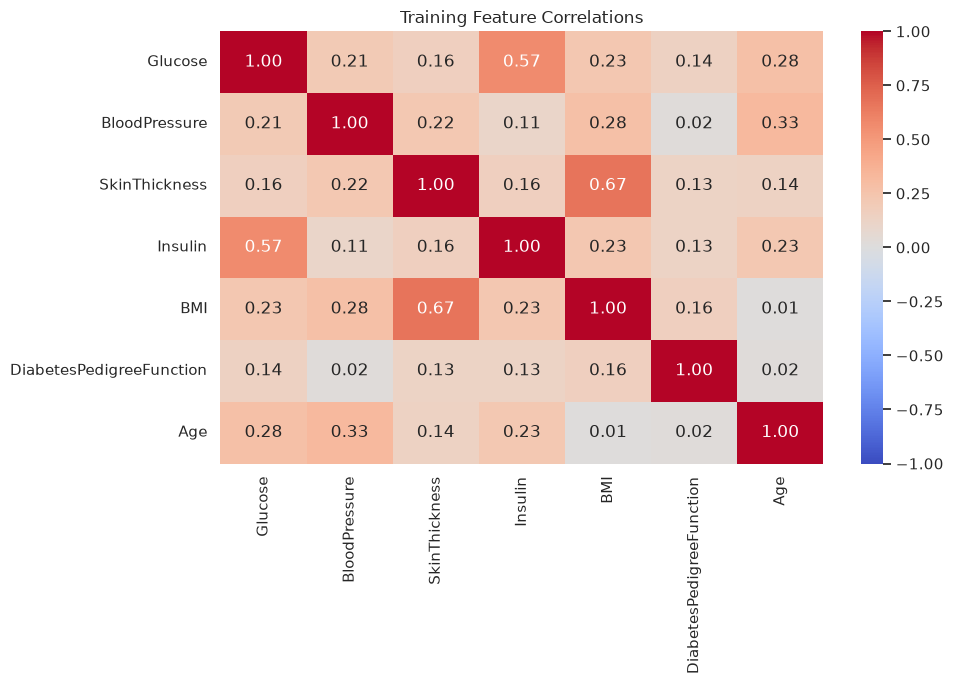

In [ ]:
# Study feature relationships heatmap

correlation_matrix = X_train_clean.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title("Training Feature Correlations")
plt.tight_layout()

plt.savefig(
    FIGURES_DIRECTORY / "training_correlations.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

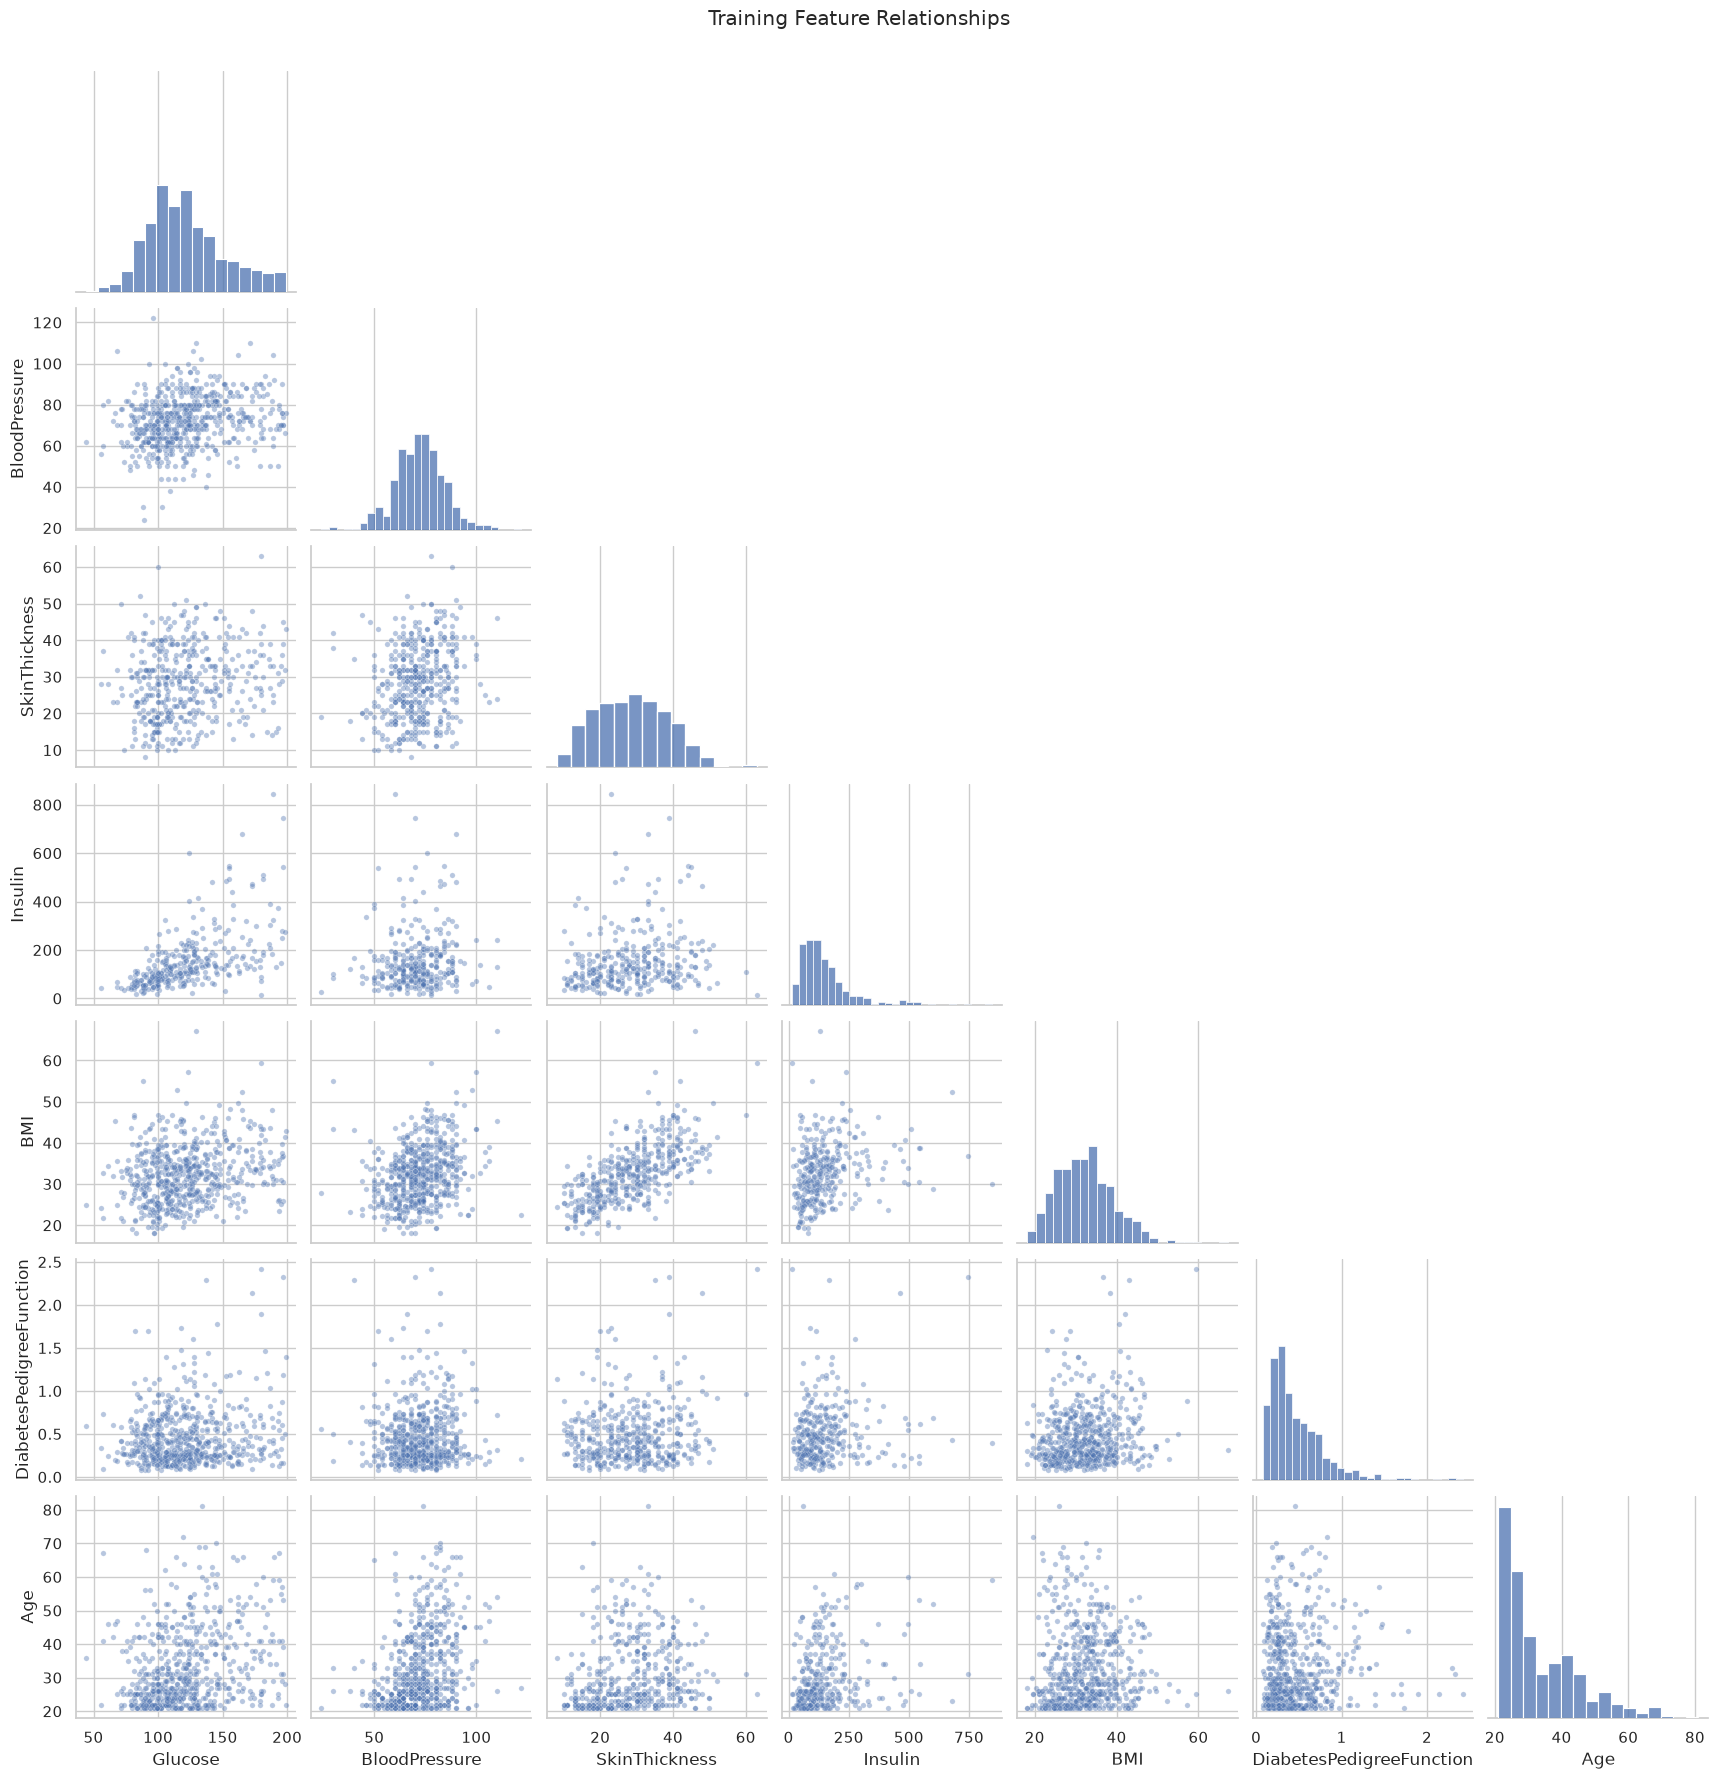

In [7]:

# Create a pairplot
pairplot = sns.pairplot(
    X_train_clean,
    diag_kind="hist",
    corner=True,
    plot_kws={
        "alpha": 0.4,
        "s": 15,
    },
)

pairplot.fig.suptitle(
    "Training Feature Relationships",
    y=1.02,
)

pairplot.savefig(
    FIGURES_DIRECTORY / "training_pairplot.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [8]:
variabilty_report = pd.DataFrame({
    "unique_observed_values": X_train_clean.nunique(),
    "standard_deviation": X_train_clean.std(),
})

display(variabilty_report.round(3))

,unique_observed_values,standard_deviation
Glucose,132,30.226
BloodPressure,43,12.343
SkinThickness,46,9.961
Insulin,166,119.818
BMI,224,6.975
DiabetesPedigreeFunction,443,0.337
Age,52,11.503


In [9]:
preprocessor = create_preprocessor()

# Learn medians, means, and standard deviations from training data.
train_scaled_array = preprocessor.fit_transform(train_data)

# Apply those same learned values to test data.
test_scaled_array = preprocessor.transform(test_data)

X_train_scaled = pd.DataFrame(
    train_scaled_array,
    columns=FEATURES,
    index=train_data.index,
)

X_test_scaled = pd.DataFrame(
    test_scaled_array,
    columns=FEATURES,
    index=test_data.index,
)

display(X_train_scaled.head())

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
source_row,,,,,,,
60,-1.257201,-0.018995,-0.008140,-0.204516,-0.050247,-0.490735,-1.035940
618,-0.326334,0.808174,-0.543652,-0.204516,-0.598590,2.415030,1.487101
346,0.571288,-2.169636,-1.138665,-0.622227,-0.526439,0.549161,-0.948939
294,1.302683,-1.838768,-0.008140,-0.204516,-1.507685,-0.639291,2.792122
231,0.405061,0.642740,1.003382,2.617853,1.998825,-0.686829,1.139095


In [10]:
imputer = preprocessor.named_steps["imputer"]
scaler = preprocessor.named_steps["scaler"]

preprocessing_summary = pd.DataFrame({
    "imputation_median": imputer.statistics_,
    "scaling_mean": scaler.mean_,
    "scaling_std": scaler.scale_,
}, index=FEATURES)

display(preprocessing_summary.round(3))

preprocessing_summary.to_csv(
    METRICS_DIRECTORY / "preprocessing_summary.csv",
    index_label="feature",
)

,imputation_median,scaling_mean,scaling_std
Glucose,118.000,121.816,30.079
BloodPressure,72.000,72.230,12.089
SkinThickness,28.500,28.568,8.403
Insulin,120.000,138.116,88.578
BMI,32.000,32.348,6.930
DiabetesPedigreeFunction,0.372,0.469,0.337
Age,29.000,32.907,11.494


In [11]:
assert X_train_scaled.shape == (len(train_data), len(FEATURES))
assert X_test_scaled.shape == (len(test_data), len(FEATURES))

assert np.isfinite(X_train_scaled.to_numpy()).all()
assert np.isfinite(X_test_scaled.to_numpy()).all()

scaling_check = pd.DataFrame({
    "training_mean": X_train_scaled.mean(),
    "training_std": X_train_scaled.std(ddof=0),
})

display(scaling_check.round(6))

,training_mean,training_std
Glucose,-0.0,1.0
BloodPressure,-0.0,1.0
SkinThickness,-0.0,1.0
Insulin,0.0,1.0
BMI,0.0,1.0
DiabetesPedigreeFunction,0.0,1.0
Age,-0.0,1.0


In [12]:
preprocessor_path = (
    MODELS_DIRECTORY / "preprocessor.joblib"
)

joblib.dump(
    preprocessor,
    preprocessor_path,
)

X_train_scaled.to_csv(
    PROCESSED_DIRECTORY / "train_scaled.csv",
    index_label="source_row",
)

X_test_scaled.to_csv(
    PROCESSED_DIRECTORY / "test_scaled.csv",
    index_label="source_row",
)

print("Preprocessor and scaled datasets saved.")

Preprocessor and scaled datasets saved.


In [13]:
loaded_preprocessor = joblib.load(
    preprocessor_path
)

reloaded_result = loaded_preprocessor.transform(
    test_data
)

np.testing.assert_allclose(
    reloaded_result,
    X_test_scaled.to_numpy(),
)

print("Reloaded preprocessing gives identical results.")

Reloaded preprocessing gives identical results.


## Preprocessing decisions

- Reused the training/test split created on Day 1.
- Excluded the exported row index from model inputs.
- Selected the seven features specified in the project brief.
- Treated zeros in Glucose, BloodPressure, SkinThickness,
  Insulin, and BMI as missing measurements.
- Filled missing measurements using training-set medians.
- Detected potential outliers using training-set IQR limits.
- Retained unusual observations for the baseline.
- Standardized features using training-set statistics.
- Saved feature preparation, imputation, and scaling together.

## Limitations and follow-up

- Almost half of Insulin measurements are recorded as zero.
- Median imputation can change distributions and relationships.
- Extreme observations may still influence K-Means.
- Compare alternative preprocessing choices using training data.